In [1]:
# importing the neccessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error as RMSE, mean_absolute_error as MAE

In [2]:
# Load Data
railway_df = pd.read_csv("CleanedRailway.csv", parse_dates=['Date of Journey', 'Date of Purchase'])
display(railway_df.head())
display(railway_df.info())

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,...,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Delay Duration,Journey ID,Route Code
0,da8a6ba8-b3dc-4677-b176,2023-12-08,2023-12-08 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,...,2024-01-01,2024-01-01 11:00:00,2024-01-01 13:30:00,2024-01-01 13:30:00,On Time,NaN,No,0 days 00:00:00,PAD-LIV:20240101:1100,PAD-LIV
1,b0cdd1b0-f214-4197-be53,2023-12-16,2023-12-16 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,...,2024-01-01,2024-01-01 09:45:00,2024-01-01 11:35:00,2024-01-01 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,KGX-YRK:20240101:0945,KGX-YRK
2,f3ba7a96-f713-40d9-9629,2023-12-19,2023-12-19 19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,...,2024-01-02,2024-01-02 18:15:00,2024-01-02 18:45:00,2024-01-02 18:45:00,On Time,NaN,No,0 days 00:00:00,LIV-MAN:20240102:1815,LIV-MAN
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,2023-12-20 23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,...,2024-01-01,2024-01-01 21:30:00,2024-01-01 22:30:00,2024-01-01 22:30:00,On Time,NaN,No,0 days 00:00:00,PAD-RDG:20240101:2130,PAD-RDG
4,2be00b45-0762-485e-a7a3,2023-12-27,2023-12-27 18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,...,2024-01-01,2024-01-01 16:45:00,2024-01-01 19:00:00,2024-01-01 19:00:00,On Time,NaN,No,0 days 00:00:00,LIV-EUS:20240101:1645,LIV-EUS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  object        
 1   Date of Purchase     31653 non-null  datetime64[ns]
 2   Time of Purchase     31653 non-null  object        
 3   Purchase Type        31653 non-null  object        
 4   Payment Method       31653 non-null  object        
 5   Railcard             31653 non-null  object        
 6   Ticket Class         31653 non-null  object        
 7   Ticket Type          31653 non-null  object        
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  object        
 10  Arrival Destination  31653 non-null  object        
 11  Date of Journey      31653 non-null  datetime64[ns]
 12  Departure Time       31653 non-null  object        
 13  Arrival Time         31653 non-

None

In [3]:
# Load the calendar table
calendar = pd.read_csv('Calendar.csv', parse_dates=['Date'])
display(calendar)
calendar.info()

,Date,Year,Quarter,Month,Month Name,Week,Day of Week,Day Type,Holiday Name
0,2023-12-01,2023,4,12,Dec,48,Fri,Workday,NaN
1,2023-12-02,2023,4,12,Dec,48,Sat,Weekend,NaN
2,2023-12-03,2023,4,12,Dec,48,Sun,Weekend,NaN
3,2023-12-04,2023,4,12,Dec,49,Mon,Workday,NaN
4,2023-12-05,2023,4,12,Dec,49,Tue,Workday,NaN
...,...,...,...,...,...,...,...,...,...
178,2024-05-27,2024,2,5,May,22,Mon,Holiday,Spring bank holiday
179,2024-05-28,2024,2,5,May,22,Tue,Workday,NaN
180,2024-05-29,2024,2,5,May,22,Wed,Workday,NaN
181,2024-05-30,2024,2,5,May,22,Thu,Workday,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          183 non-null    datetime64[ns]
 1   Year          183 non-null    int64         
 2   Quarter       183 non-null    int64         
 3   Month         183 non-null    int64         
 4   Month Name    183 non-null    object        
 5   Week          183 non-null    int64         
 6   Day of Week   183 non-null    object        
 7   Day Type      183 non-null    object        
 8   Holiday Name  7 non-null      object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 13.0+ KB


### Aggregate daily data


In [4]:
# Aggregate daily data
daily_data = railway_df.groupby('Date of Journey').agg(
    # Booking metrics
    Bookings=('Transaction ID', 'count'),  # Count all tickets sold
    Journeys= ('Journey ID', 'nunique'),   # Count distinct Journeys

    # Journey status metrics
    Delayed_Journeys= ('Journey ID', lambda x: (x[railway_df['Journey Status'] == 'Delayed'].nunique())),
    Cancelled_Journeys= ('Journey ID', lambda x: (x[railway_df['Journey Status'] == 'Cancelled'].nunique())),
                         
    # Financial metrics
    Revenue=('Price', 'sum'),
    Refunded=('Price', lambda x: x[railway_df['Refund Request'] == 'Yes'].sum()),

    # First Class demand
    First_Class=('Ticket Class', lambda x: (x == 'First Class').sum()),
).reset_index()

# Display the processed dataframe
daily_data

,Date of Journey,Bookings,Journeys,Delayed_Journeys,Cancelled_Journeys,Revenue,Refunded,First_Class
0,2024-01-01,66,61,5,0,1682,41,4
1,2024-01-02,146,112,6,8,4830,102,19
2,2024-01-03,292,168,10,8,7159,437,31
3,2024-01-04,274,176,7,9,7063,560,25
4,2024-01-05,253,159,8,3,5934,202,22
...,...,...,...,...,...,...,...,...
116,2024-04-26,270,173,11,6,6125,274,31
117,2024-04-27,269,161,12,8,6707,598,25
118,2024-04-28,292,190,8,9,6655,250,36
119,2024-04-29,249,160,8,6,5893,430,27


In [5]:
# Merge calendar data with transaction data
daily_data = pd.merge(
    # Calendar features (date-related attributes)
    calendar[['Date', 'Month', 'Week', 'Day of Week', 'Day Type']],
    daily_data[['Date of Journey', 'Bookings', 'Journeys', 'First_Class', 'Revenue']],
    how="inner",  # Keep only matching records
    left_on='Date',  # Join key from calendar
    right_on='Date of Journey'  # Join key from transactions
)

# Remove duplicate date column (keep 'Date' from calendar)
daily_data = daily_data.drop(columns=['Date of Journey'])

# Convert day of week to numerical index (Monday=0 to Sunday=6)
daily_data['Day of Week'] = daily_data['Date'].dt.dayofweek

# Display the processed dataframe
daily_data

,Date,Month,Week,Day of Week,Day Type,Bookings,Journeys,First_Class,Revenue
0,2024-01-01,1,1,0,Holiday,66,61,4,1682
1,2024-01-02,1,1,1,Workday,146,112,19,4830
2,2024-01-03,1,1,2,Workday,292,168,31,7159
3,2024-01-04,1,1,3,Workday,274,176,25,7063
4,2024-01-05,1,1,4,Workday,253,159,22,5934
...,...,...,...,...,...,...,...,...,...
116,2024-04-26,4,17,4,Workday,270,173,31,6125
117,2024-04-27,4,17,5,Weekend,269,161,25,6707
118,2024-04-28,4,17,6,Weekend,292,190,36,6655
119,2024-04-29,4,18,0,Workday,249,160,27,5893


In [6]:
# Display Daily date column names:
print('Columns in the dataset:')
display(daily_data.columns.tolist())

Columns in the dataset:


['Date',
 'Month',
 'Week',
 'Day of Week',
 'Day Type',
 'Bookings',
 'Journeys',
 'First_Class',
 'Revenue']

In [7]:
daily_data.describe()[['Bookings','Journeys', 'First_Class', 'Revenue']].round(1)

,Bookings,Journeys,First_Class,Revenue
count,121.0,121.0,121.0,121.0
mean,261.6,164.2,25.3,6131.6
min,63.0,55.0,4.0,1562.0
25%,253.0,161.0,21.0,5546.0
50%,269.0,168.0,25.0,6227.0
75%,282.0,173.0,30.0,7003.0
max,313.0,192.0,40.0,9196.0
std,40.0,21.3,6.3,1132.2


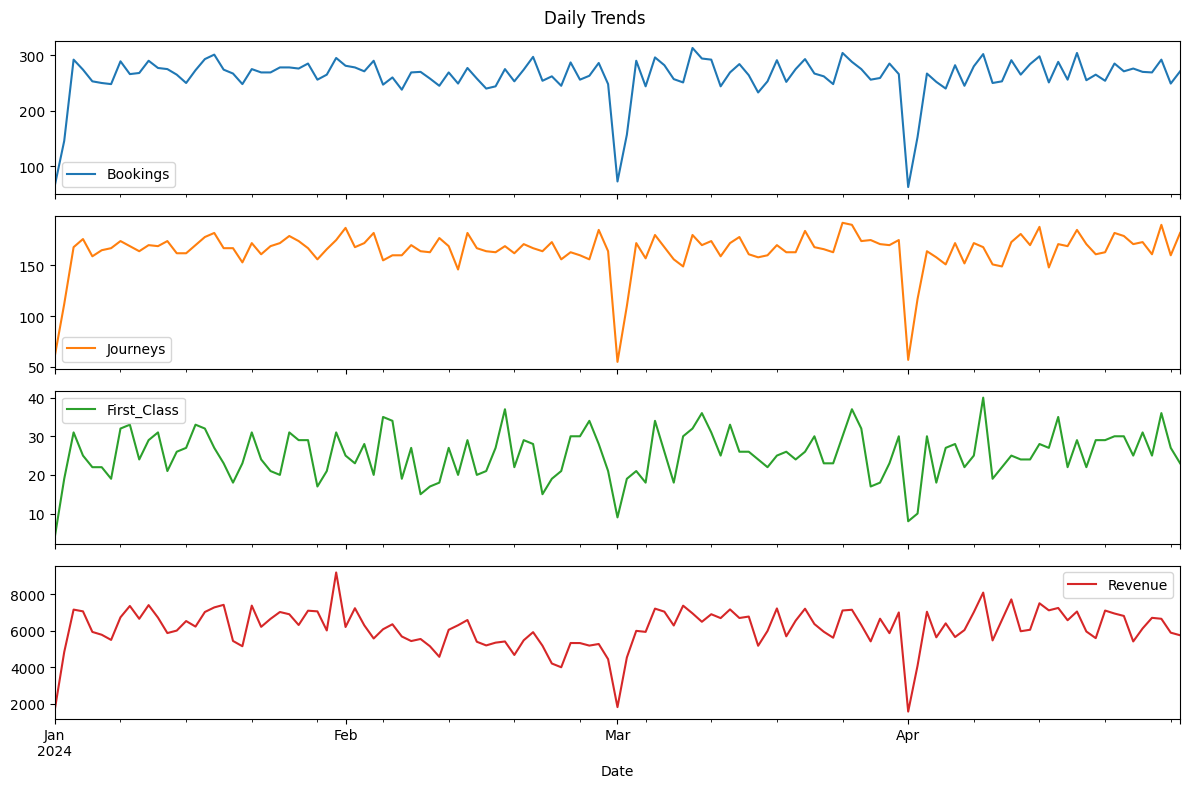

In [8]:
# ----------------------------------------
# 1. Daily Data Analysis
# ----------------------------------------
# Plot daily trends for all targets
targets = ['Bookings', 'Journeys','First_Class', 'Revenue']
daily_data.set_index('Date')[targets].plot(subplots=True, figsize=(12, 8), title='Daily Trends')
plt.tight_layout()
plt.show()

Do holidays show spikes/drops in cancellations or revenue?

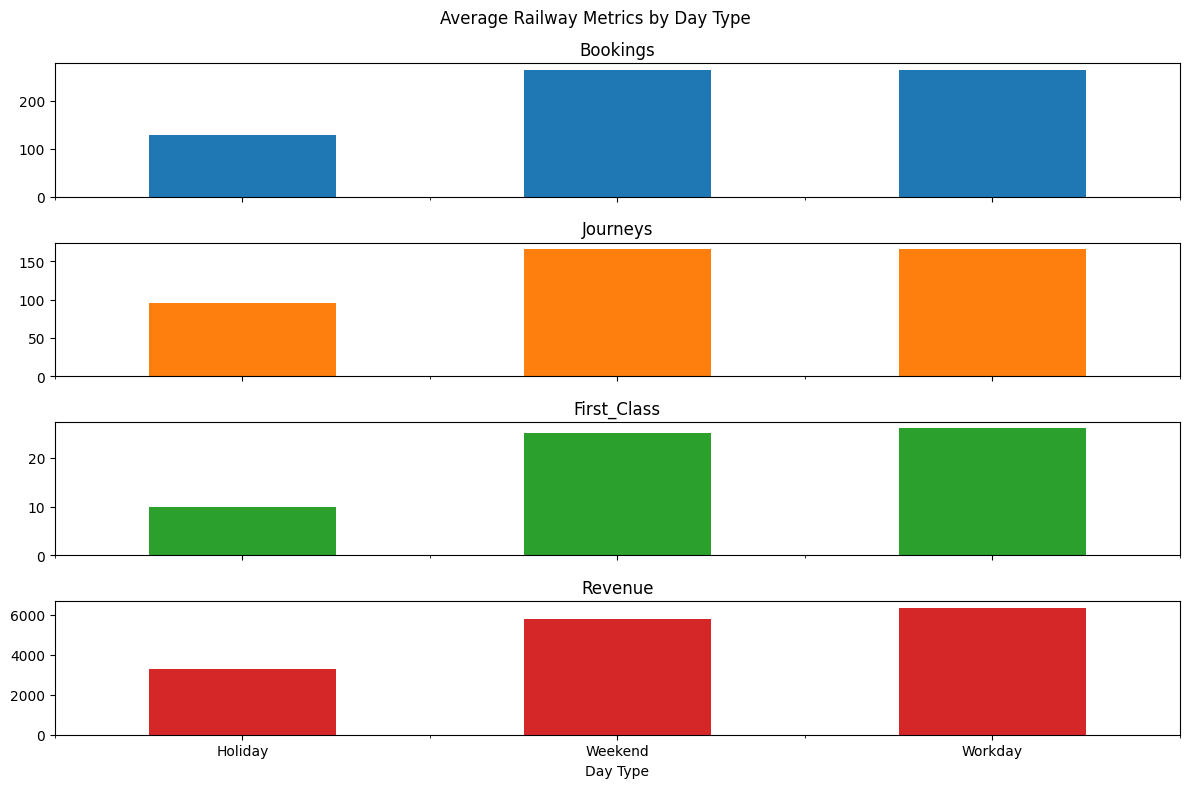

,Bookings,Journeys,First_Class,Revenue
Day Type,,,,
Holiday,129,96,10,3301
Weekend,264,166,25,5794
Workday,265,166,26,6369


In [9]:
# Calculate average metrics by day type
daily_metrics_by_day_type = daily_data.groupby('Day Type')[
    ['Bookings', 'Journeys', 'First_Class', 'Revenue']
].mean().round().astype('int')

# Create bar plot with descriptive title
daily_metrics_by_day_type.plot.bar(
    subplots=True,
    figsize=(12, 8),
    title='Average Railway Metrics by Day Type',
    rot=0,  # Rotate x-axis labels for better readability
    legend=False  # Since we're using subplots, legends are redundant
)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Return the calculated metrics
daily_metrics_by_day_type

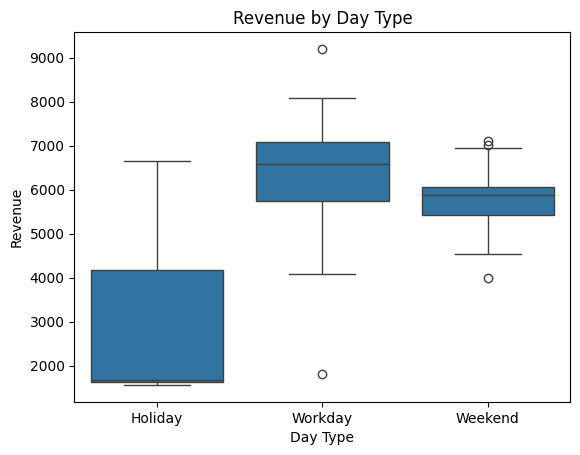

In [10]:
# Analyze Day Type impact (e.g., Revenue by Workday/Weekend/Holiday)
sns.boxplot(data=daily_data, x='Day Type', y='Revenue')
plt.title('Revenue by Day Type')
plt.show()

Is there a monthly trend (e.g., increasing bookings over time)?

,Bookings,Journeys,Revenue
Month,,,
1,8111,5060,199618
2,7644,4839,159374
3,8117,5083,195147
4,7781,4889,187782


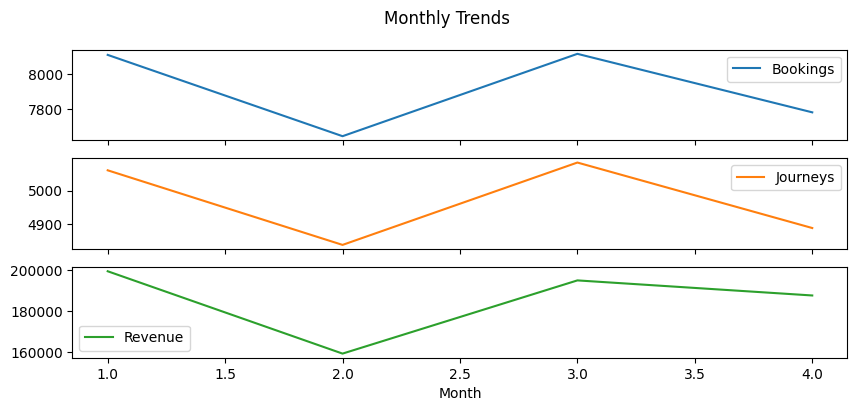

In [11]:
# ----------------------------------------
# 2. Monthly Data Analysis
# ----------------------------------------
# Aggregate to monthly trends (if needed)
monthly_trends = daily_data.groupby('Month')[['Bookings', 'Journeys', 'Revenue']].sum()
monthly_trends.plot(subplots=True, figsize=(10, 4), title='Monthly Trends')
# plt.show()
monthly_trends

2. Feature Engineering & Encoding

#### 2. Feature Encoding

In [12]:
# Cyclical encoding
def encode_cyclical(df, col, max_val):
    df[col+'_sin'] = np.sin(2 * np.pi * df[col]/max_val)
    df[col+'_cos'] = np.cos(2 * np.pi * df[col]/max_val)
    return df

df = daily_data

df = encode_cyclical(df, 'Day of Week', 7)

# Binary flags
df['Is_Weekend'] = (df['Day Type'] == 'Weekend').astype(int)
df['Is_Holiday'] = (df['Day Type'] == 'Holiday').astype(int)

# Drop original temporal columns
df = df.drop(columns=['Day of Week', 'Day Type'])
# df = df.drop(columns=[ 'Day Type'])

# Display the new dataframe
display(df)

,Date,Month,Week,Bookings,Journeys,First_Class,Revenue,Day of Week_sin,Day of Week_cos,Is_Weekend,Is_Holiday
0,2024-01-01,1,1,66,61,4,1682,0.000000,1.000000,0,1
1,2024-01-02,1,1,146,112,19,4830,0.781831,0.623490,0,0
2,2024-01-03,1,1,292,168,31,7159,0.974928,-0.222521,0,0
3,2024-01-04,1,1,274,176,25,7063,0.433884,-0.900969,0,0
4,2024-01-05,1,1,253,159,22,5934,-0.433884,-0.900969,0,0
...,...,...,...,...,...,...,...,...,...,...,...
116,2024-04-26,4,17,270,173,31,6125,-0.433884,-0.900969,0,0
117,2024-04-27,4,17,269,161,25,6707,-0.974928,-0.222521,1,0
118,2024-04-28,4,17,292,190,36,6655,-0.781831,0.623490,1,0
119,2024-04-29,4,18,249,160,27,5893,0.000000,1.000000,0,0


In [13]:
# df.to_csv('Daily Data.csv', index=False)

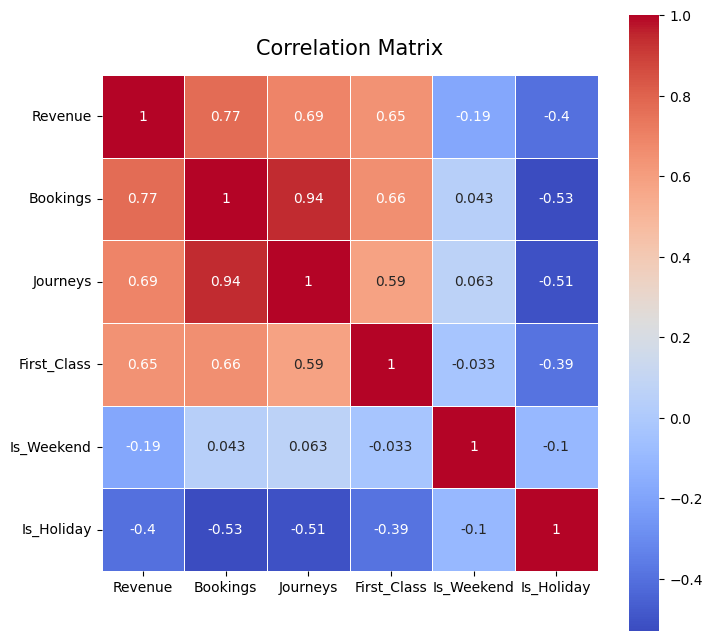

In [14]:
# Compute the correlation matrix
corr =  df[['Revenue',
            'Bookings',
            'Journeys',
            'First_Class',
            'Is_Weekend',
            'Is_Holiday']].corr()

# Plot the correlation matrix using Seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,        # Display correlation values
    cmap="coolwarm",  # Use the coolwarm colormap
    #vmin=-1,          # Minimum value for colormap (correlation ranges from -1 to 1)
    #vmax=1,           # Maximum value for colormap
    linewidths=0.5,   # Add lines between cells
    square=True       # Ensure cells are square-shaped
)

# Add a title
plt.title("Correlation Matrix", pad=15, fontsize=15)
plt.yticks(rotation=0)

# Display the plot
plt.show()

# Forecasting the Revenue using Prophet
* Pros:
    * Excellent at capturing multiple seasonalities (daily, weekly, yearly).
    * Easily including additional regressors (like weekend and holiday indicators).
    * User-friendly with interpretable components (trend, seasonality, holidays).
* Cons:
    * Might be less flexible in very short-term dynamics compared to more tailored models.


In [15]:
from prophet import Prophet

# Prepare the DataFrame for Prophet: ds and y. Also include extra regressors: Is_Holiday and Is_Weekend.
prophet_df = df[['Date', 'Revenue', 'Is_Holiday', 'Is_Weekend']].rename(columns={'Date':'ds', 'Revenue':'y'})

# Initialize the Prophet model
model = Prophet(daily_seasonality=True, weekly_seasonality=True, seasonality_mode='multiplicative')

# Add extra regressors
model.add_regressor('Is_Holiday')
model.add_regressor('Is_Weekend')

# Fit the mod
model.fit(prophet_df)

print('Prophet model fitted on Journeys with regressors Is_Holiday and Is_Weekend.')

05:35:09 - cmdstanpy - INFO - Chain [1] start processing
05:35:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted on Journeys with regressors Is_Holiday and Is_Weekend.


In [16]:
# Create a dataframe to hold predictions for the next 31 days
may = calendar[
    (calendar['Date'] >= '2024-05-01') & (calendar['Date'] <= '2024-05-31')
    ][['Date', 'Day Type']].reset_index(drop=True)

# Rename the "Date" to 'ds'
may_ds = may.rename(columns={'Date': 'ds'})

# Binary flags
may_ds['Is_Weekend'] = (may_ds['Day Type'] == 'Weekend').astype(int)
may_ds['Is_Holiday'] = (may_ds['Day Type'] == 'Holiday').astype(int)

# Drop the original 'Day Type' column
may_ds = may_ds.drop(columns=['Day Type'])

# Display the new dataframe
# display(may_ds)

In [17]:
# Forecast using the model
forecast = model.predict(may_ds)

In [18]:
# Display forecast output
forecasted = pd.merge(
    may,
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    how='left',
    left_on='Date',
    right_on='ds'
).drop(columns='ds')

# Round to 1 decimal place
forecasted[['yhat', 'yhat_lower', 'yhat_upper']] = forecasted[['yhat', 'yhat_lower', 'yhat_upper']].round(1)
forecasted = forecasted.rename(columns={'yhat': 'Forecasted Revenue', })

print("Forecasted:")
display(forecasted)

print(f"\nPrediced Total Revenue for May 2024 = {forecasted['Forecasted Revenue'].sum().round(0).astype(int)} £")

Forecasted:


,Date,Day Type,Forecasted Revenue,yhat_lower,yhat_upper
0,2024-05-01,Workday,6846.2,5579.6,8097.6
1,2024-05-02,Workday,6322.7,5107.9,7646.7
2,2024-05-03,Workday,6536.0,5306.2,7760.3
3,2024-05-04,Weekend,5832.6,4649.5,7064.2
4,2024-05-05,Weekend,6023.0,4733.7,7283.1
5,2024-05-06,Holiday,3245.8,1984.1,4481.9
6,2024-05-07,Workday,6411.5,5273.3,7646.6
7,2024-05-08,Workday,6864.5,5599.5,8112.8
8,2024-05-09,Workday,6339.6,5044.8,7546.7
9,2024-05-10,Workday,6553.5,5233.8,7815.2



Prediced Total Revenue for May 2024 = 191962 £


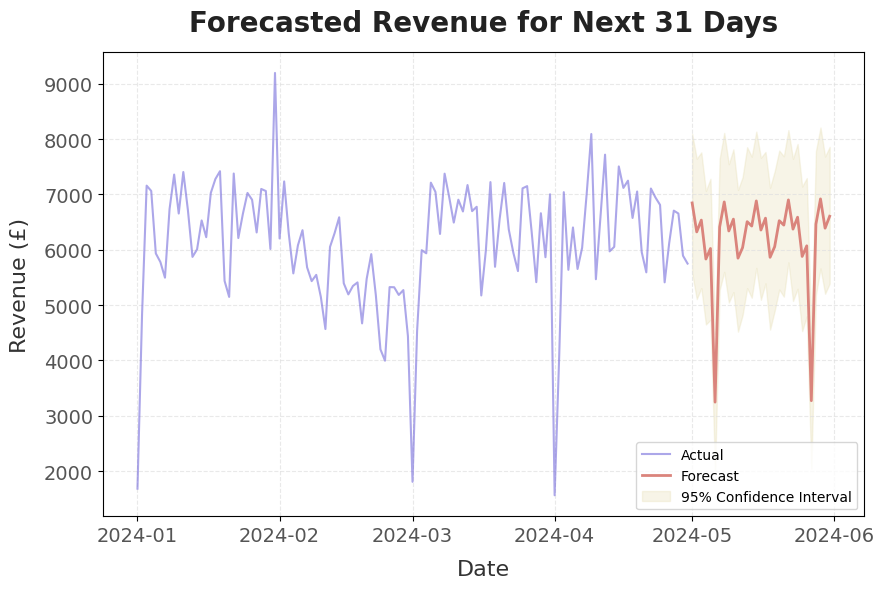

In [19]:
# Set up the plot with scientific theme
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Plot actual data
plt.plot(prophet_df['ds'], prophet_df['y'], '-', color='#766CDB', alpha=0.6, label='Actual')

# Plot forecast
plt.plot(forecast['ds'], forecast['yhat'], '-', color='#DA847C', linewidth=2, label='Forecast')

# Plot confidence intervals
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 color='#D9CC8B', alpha=0.2, label='95% Confidence Interval')

# Formatting
plt.title('Forecasted Revenue for Next 31 Days', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.xlabel('Date', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.ylabel('Revenue (£)', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.grid(True, linestyle='--', alpha=0.7, color='#E0E0E0')
plt.legend(loc='lower right', fontsize=10)
plt.xticks(fontsize=14, color='#555555')
plt.yticks(fontsize=14, color='#555555')

# Show the plot
plt.tight_layout()
plt.show()

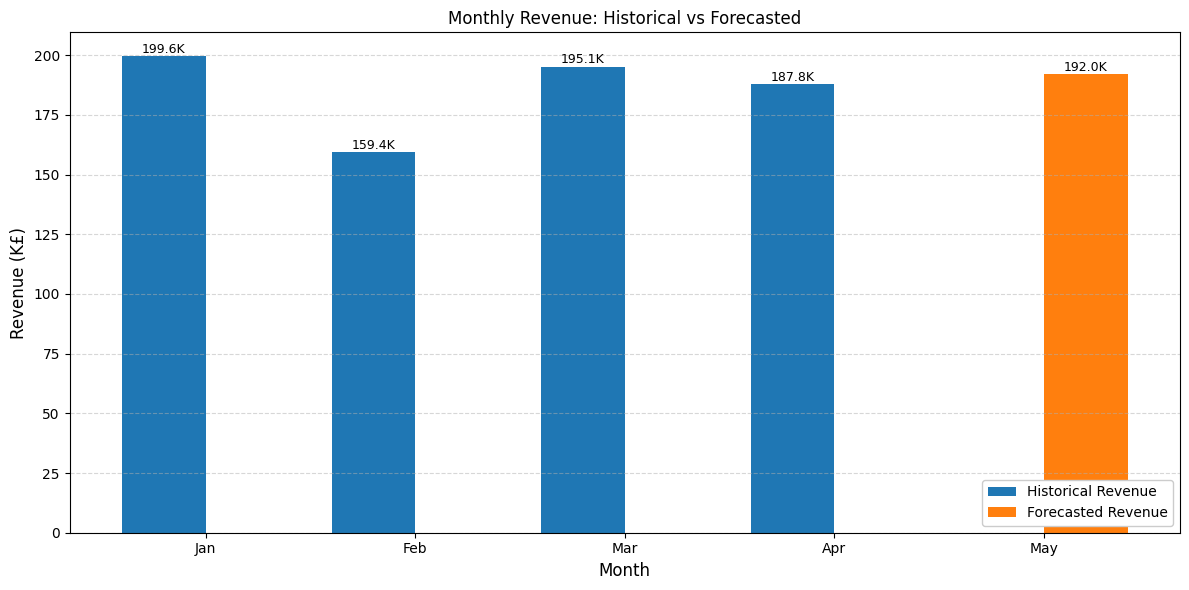

In [20]:
# Aggregate historical revenue to monthly
historical_monthly = (
    daily_data.groupby('Month')[['Revenue']]
    .sum()
    .rename(columns={'Revenue': 'Historical Revenue'})
)

# Ensure 'Date' in forecasted is datetime and extract month
forecasted['Date'] = pd.to_datetime(forecasted['Date'])
forecasted['Month'] = forecasted['Date'].dt.month

# Aggregate forecasted revenue to monthly
forecasted_monthly = (
    forecasted.groupby('Month')[['Forecasted Revenue']]
    .sum()
)

# Combine both into one DataFrame and convert to thousands
combined = pd.concat([historical_monthly, forecasted_monthly], axis=1) / 1000

# Filter out rows where BOTH historical and forecasted are zero
combined = combined[
    (combined['Historical Revenue'] != 0) | 
    (combined['Forecasted Revenue'] != 0)
]

# Map month numbers to names (e.g., 1 → "Jan")
combined.index = combined.index.map(
    lambda x: pd.to_datetime(str(x), format='%m').strftime('%b')
)

# Plot
ax = combined.plot(
    kind='bar',
    figsize=(12, 6),
    title='Monthly Revenue: Historical vs Forecasted',
    color=['#1f77b4', '#ff7f0e'],  # Blue for historical, orange for forecasted
    width=0.8,
    rot=0
)

# Add value annotations (only for non-zero bars)
for p in ax.patches:
    height = p.get_height()
    if height != 0:  # Skip zero values
        ax.annotate(
            f"{height:,.1f}K",  # Format with 1 decimal and "K" suffix
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=9
        )

# Customize plot
plt.ylabel('Revenue (K£)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(
    ['Historical Revenue', 'Forecasted Revenue'], 
    loc='lower right',
    framealpha=1
)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error as MAE, \
                            mean_absolute_percentage_error as MAPE, \
                            mean_squared_error as MSE, \
                            r2_score
import numpy as np

# Calculate model performance metrics on the training data
y_true = prophet_df['y'].values
y_pred = model.predict(prophet_df)['yhat'].values

# Compute metrics
rmse = np.sqrt(MSE(y_true, y_pred))
mae = MAE(y_true, y_pred)
mape = MAPE(y_true, y_pred) * 100  # convert to percentage
r2 = r2_score(y_true, y_pred) * 100  # convert to percentage if you want %

# Display results
print("Model Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.2f}%")

Model Performance Metrics:
RMSE: 985.46
MAE: 726.53
MAPE: 14.76%
R²: 23.62%


In [22]:
# Read the Forecasted May csv file with proper date parsing
forecasted_may = pd.read_csv('Forecasted May.csv', parse_dates=['Date'])

# Merge forecasted revenue data
forecasted_may = pd.merge(
    forecasted_may,
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    how='left',
    left_on='Date',
    right_on='ds'
).drop(columns='ds')

# Round to 1 decimal place
forecasted_may[['yhat', 'yhat_lower', 'yhat_upper']] = forecasted_may[['yhat', 'yhat_lower', 'yhat_upper']].round(1)
forecasted_may = forecasted_may.rename(columns={'yhat': 'Revenue', 'yhat_lower': 'Revenue_lower', 'yhat_upper': 'Revenue_upper'})

# Save the forecasted values into csv file
forecasted_may.to_csv('Forecasted May.csv', index=False)

In [23]:
forecasted_may

,Date,Day Type,Bookings,Booknigs_lower,Booking_upper,Journeys,Journeys_lower,Journeys_upper,First Class,First Class_lower,First Class_upper,Revenue,Revenue_lower,Revenue_upper,Revenue,Revenue_lower,Revenue_upper
0,2024-05-01,Workday,281,238,326,173,148,197,29,22,35,6846.2,5683.7,8146.1,6846.2,5579.6,8097.6
1,2024-05-02,Workday,274,233,317,173,150,196,23,17,31,6322.7,5039.2,7591.4,6322.7,5107.9,7646.7
2,2024-05-03,Workday,269,227,310,168,143,190,26,19,33,6536.0,5418.5,7817.2,6536.0,5306.2,7760.3
3,2024-05-04,Weekend,264,226,305,167,143,188,25,18,32,5832.6,4509.6,7147.4,5832.6,4649.5,7064.2
4,2024-05-05,Weekend,275,232,319,170,147,192,27,20,34,6023.0,4788.4,7236.1,6023.0,4733.7,7283.1
5,2024-05-06,Holiday,130,91,174,90,66,113,10,4,17,3245.8,2055.1,4545.6,3245.8,1984.1,4481.9
6,2024-05-07,Workday,261,217,303,164,139,185,29,22,36,6411.5,5188.0,7617.2,6411.5,5273.3,7646.6
7,2024-05-08,Workday,282,239,325,173,149,195,29,22,36,6864.5,5496.0,8071.3,6864.5,5599.5,8112.8
8,2024-05-09,Workday,275,236,316,173,150,196,24,17,31,6339.6,5074.4,7636.9,6339.6,5044.8,7546.7
9,2024-05-10,Workday,270,226,314,168,144,192,26,20,33,6553.5,5353.4,7815.4,6553.5,5233.8,7815.2


***

# Forecasting the Revenue using Random Forest Regressor

Machine Learning Approaches (e.g., Random Forest, XGBoost):
* Pros:
    * Can capture non-linear relationships and interactions between features, potentially providing more accurate forecasts if engineered well.
    * Can incorporate multiple regressors (holiday flags, weekend flags) directly as features.
* Cons:
    * Often require more data and careful feature engineering to avoid overfitting.
    * They can be less interpretable compared to classical time series models.


In [24]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
import warnings
warnings.filterwarnings("ignore"
                        , #category=DeprecationWarning  # Example for DeprecationWarning
                       )

In [26]:
# Create features
# Extract day, month features from Date
df['Day'] = df['Date'].dt.day

# Select features
features = ['Bookings', 'Journeys', 'First_Class', 'Is_Weekend', 'Is_Holiday', 'Day', 'Month', 'Day of Week_sin', 'Day of Week_cos']
X = df[features]
y = df['Revenue']

Random Forest Model Evaluation:
Mean Squared Error (MSE): 619029.01
Root Mean Squared Error (RMSE): 776.18
Mean Absolute Error (MAE): 639.00
R² Score: 0.4932

Linear Regression Model Evaluation (Baseline):
Mean Squared Error (MSE): 848368.02
Root Mean Squared Error (RMSE): 920.69
Mean Absolute Error (MAE): 792.21
R² Score: 0.2977

Feature Importance:
           Feature  Importance
0         Bookings    0.342261
2      First_Class    0.210462
1         Journeys    0.165064
5              Day    0.143581
6            Month    0.059861
7  Day of Week_sin    0.035803
8  Day of Week_cos    0.020141
3       Is_Weekend    0.017586
4       Is_Holiday    0.005242


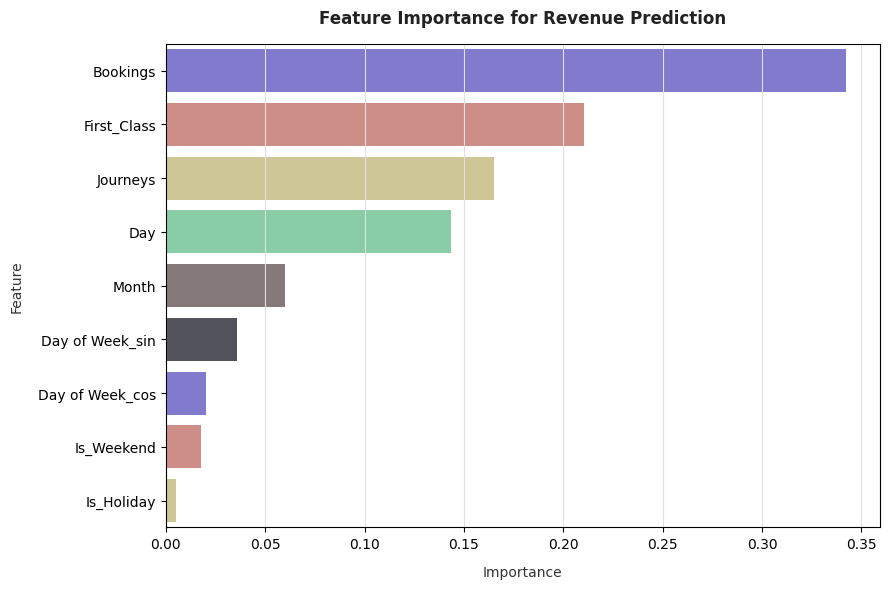

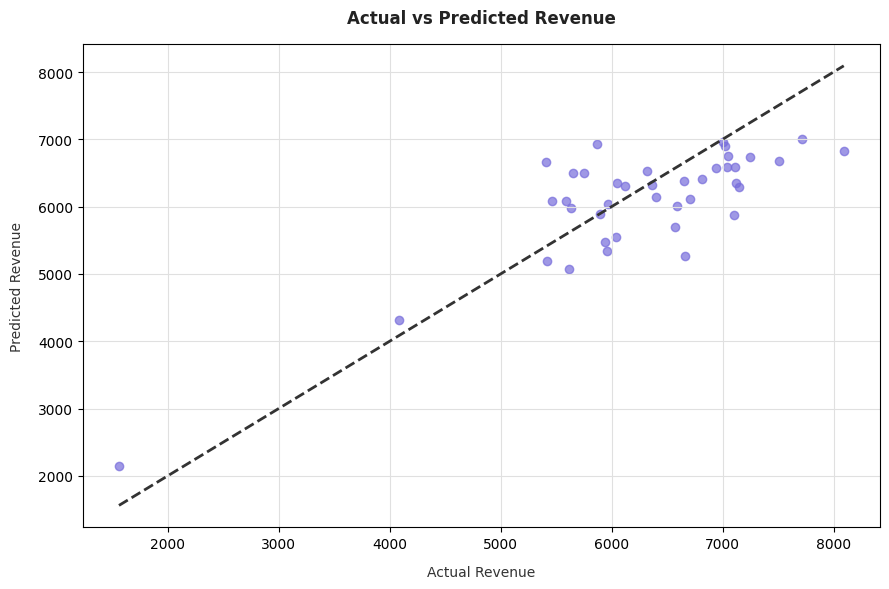

Model evaluation completed.


In [27]:
# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=2)  # You can adjust the number of splits

# Train and evaluate Random Forest model using TimeSeriesSplit
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_mse_list, rf_rmse_list, rf_mae_list, rf_r2_list = [], [], [], []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    # Make predictions
    rf_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_rmse = np.sqrt(rf_mse)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    
    rf_mse_list.append(rf_mse)
    rf_rmse_list.append(rf_rmse)
    rf_mae_list.append(rf_mae)
    rf_r2_list.append(rf_r2)

# Average performance metrics for Random Forest
print("Random Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {np.mean(rf_mse_list):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.mean(rf_rmse_list):.2f}")
print(f"Mean Absolute Error (MAE): {np.mean(rf_mae_list):.2f}")
print(f"R² Score: {np.mean(rf_r2_list):.4f}")

# Compare with Linear Regression as baseline
lr_model = LinearRegression()

lr_mse_list, lr_rmse_list, lr_mae_list, lr_r2_list = [], [], [], []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    lr_model.fit(X_train, y_train)
    
    # Make predictions
    lr_pred = lr_model.predict(X_test)
    
    # Calculate metrics
    lr_mse = mean_squared_error(y_test, lr_pred)
    lr_rmse = np.sqrt(lr_mse)
    lr_mae = mean_absolute_error(y_test, lr_pred)
    lr_r2 = r2_score(y_test, lr_pred)
    
    lr_mse_list.append(lr_mse)
    lr_rmse_list.append(lr_rmse)
    lr_mae_list.append(lr_mae)
    lr_r2_list.append(lr_r2)

# Average performance metrics for Linear Regression
print("\nLinear Regression Model Evaluation (Baseline):")
print(f"Mean Squared Error (MSE): {np.mean(lr_mse_list):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.mean(lr_rmse_list):.2f}")
print(f"Mean Absolute Error (MAE): {np.mean(lr_mae_list):.2f}")
print(f"R² Score: {np.mean(lr_r2_list):.4f}")

# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette=['#766CDB', '#DA847C', '#D9CC8B', '#7CD9A5', '#877877', '#52515E'])
plt.title('Feature Importance for Revenue Prediction', pad=15, fontweight='semibold', color='#222222')
plt.xlabel('Importance', labelpad=10, color='#333333')
plt.ylabel('Feature', labelpad=10, color='#333333')
plt.grid(True, color='#E0E0E0', axis='x')
plt.tight_layout()
plt.show()

# Visualize actual vs predicted values
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.scatter(y_test, rf_pred, color='#766CDB', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='#333333')
plt.title('Actual vs Predicted Revenue', pad=15, fontweight='semibold', color='#222222')
plt.xlabel('Actual Revenue', labelpad=10, color='#333333')
plt.ylabel('Predicted Revenue', labelpad=10, color='#333333')
plt.grid(True, color='#E0E0E0')
plt.tight_layout()
plt.show()

print("Model evaluation completed.")


Random Forest Model Evaluation:
Mean Squared Error (MSE): 187845.85
Root Mean Squared Error (RMSE): 433.41
Mean Absolute Error (MAE): 324.96
Mean Absolute Percntage Error (MAE): 5.54 %
R² Score: 84.76 %

XGBoost Model Evaluation:
Mean Squared Error (MSE): 205947.28
Root Mean Squared Error (RMSE): 453.81
Mean Absolute Error (MAE): 344.08
Mean Absolute Percentage Error (MAE): 5.51 %
R² Score: 83.29 %

Linear Regression Model Evaluation (Baseline):
Mean Squared Error (MSE): 302423.25
Root Mean Squared Error (RMSE): 549.93
Mean Absolute Error (MAE): 431.68
Mean Absolute Percntage Error (MAPE): 7.78 %
R² Score: 75.46 %

Feature Importance:


,Feature,Importance
0,Bookings,0.318594
2,First_Class,0.259281
5,Day,0.155965
1,Journeys,0.146474
6,Month,0.053968
7,Day of Week_sin,0.030274
8,Day of Week_cos,0.019330
3,Is_Weekend,0.011381
4,Is_Holiday,0.004733


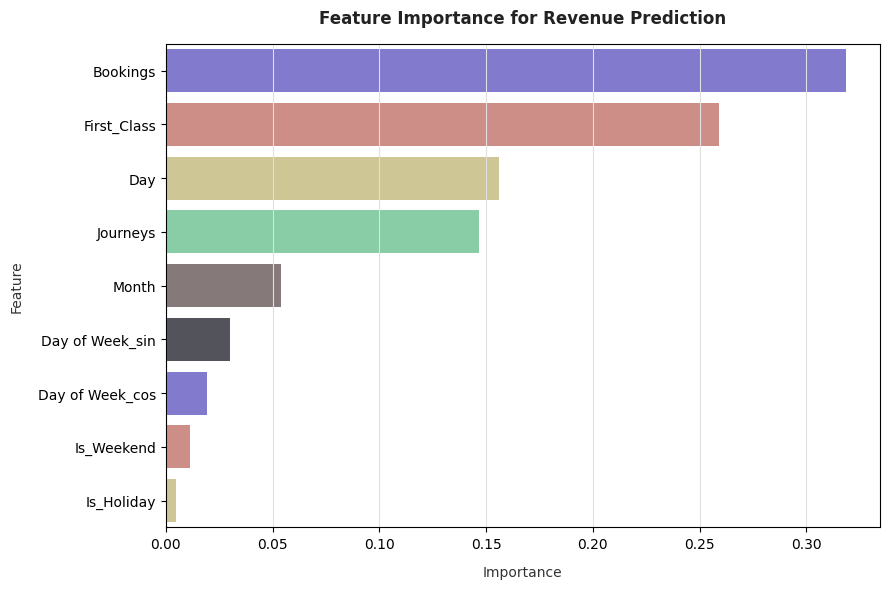

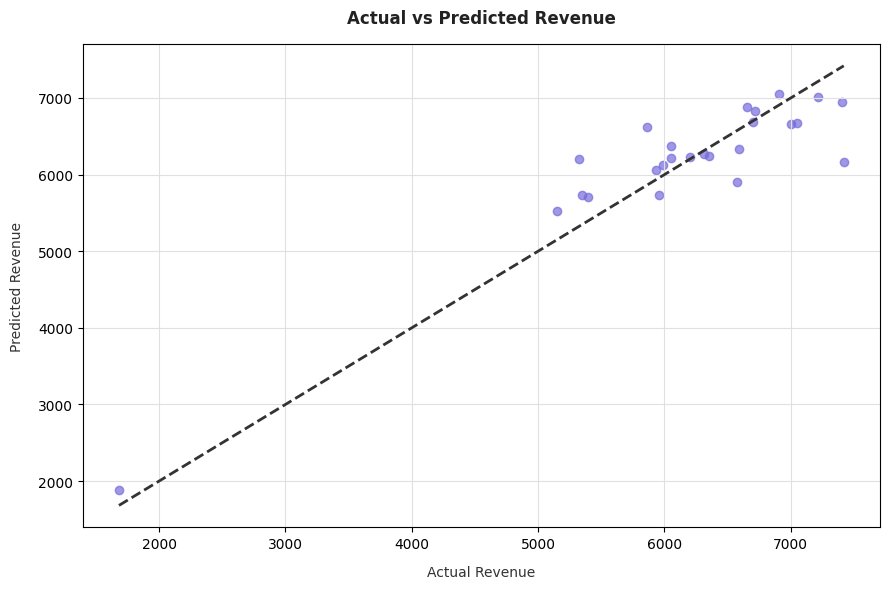

Model evaluation completed.


In [28]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Create features
# Extract day, month features from Date
df['Day'] = df['Date'].dt.day

# Select features
features = ['Bookings', 'Journeys', 'First_Class', 'Is_Weekend', 'Is_Holiday', 'Day', 'Month', 'Day of Week_sin', 'Day of Week_cos']
X = df[features]
y = df['Revenue']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=80, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
rf_r2 = r2_score(y_test, rf_pred) * 100

print("\nRandom Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Mean Absolute Percntage Error (MAE): {rf_mape:.2f} %")
print(f"R² Score: {rf_r2:.2f} %")

# Train XGBoost regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=80, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100
xgb_r2 = r2_score(y_test, xgb_pred) * 100

# Report evaluation results
print('\nXGBoost Model Evaluation:')
print(f"Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {xgb_mae:.2f}")
print(f"Mean Absolute Percentage Error (MAE): {xgb_mape:.2f} %")
print(f"R² Score: {xgb_r2:.2f} %")

# Compare with Linear Regression as baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mape = mean_absolute_percentage_error(y_test, lr_pred) * 100
lr_r2 = r2_score(y_test, lr_pred) * 100

print("\nLinear Regression Model Evaluation (Baseline):")
print(f"Mean Squared Error (MSE): {lr_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.2f}")
print(f"Mean Absolute Percntage Error (MAPE): {lr_mape:.2f} %")
print(f"R² Score: {lr_r2:.2f} %")

# Feature importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# Visualize feature importance
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette=['#766CDB', '#DA847C', '#D9CC8B', '#7CD9A5', '#877877', '#52515E'])
plt.title('Feature Importance for Revenue Prediction', pad=15, fontweight='semibold', color='#222222')
plt.xlabel('Importance', labelpad=10, color='#333333')
plt.ylabel('Feature', labelpad=10, color='#333333')
plt.grid(True, color='#E0E0E0', axis='x')
plt.tight_layout()
plt.show()

# Visualize actual vs predicted values
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.scatter(y_test, rf_pred, color='#766CDB', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='#333333')
plt.title('Actual vs Predicted Revenue', pad=15, fontweight='semibold', color='#222222')
plt.xlabel('Actual Revenue', labelpad=10, color='#333333')
plt.ylabel('Predicted Revenue', labelpad=10, color='#333333')
plt.grid(True, color='#E0E0E0')
plt.tight_layout()
plt.show()

print("Model evaluation completed.")

## Revenue Forcasting using Random Forest Regressor


Forecast Data Head:


,Bookings,Journeys,First_Class,Is_Weekend,Is_Holiday,Day,Month,Day of Week_sin,Day of Week_cos,Forecasted_Revenue
0,269.0,168.0,25.0,0,0,1,5,0.974928,-0.222521,6117.0250
1,269.0,168.0,25.0,0,0,2,5,0.433884,-0.900969,6363.7125
2,269.0,168.0,25.0,0,0,3,5,-0.433884,-0.900969,6460.8875
3,269.0,168.0,25.0,1,0,4,5,-0.974928,-0.222521,6182.6875
4,269.0,168.0,25.0,1,0,5,5,-0.781831,0.623490,6111.5875
5,269.0,168.0,25.0,0,1,6,5,0.000000,1.000000,6595.1875
6,269.0,168.0,25.0,0,0,7,5,0.781831,0.623490,6456.5625
7,269.0,168.0,25.0,0,0,8,5,0.974928,-0.222521,6590.9875
8,269.0,168.0,25.0,0,0,9,5,0.433884,-0.900969,6383.4500
9,269.0,168.0,25.0,0,0,10,5,-0.433884,-0.900969,6468.0625


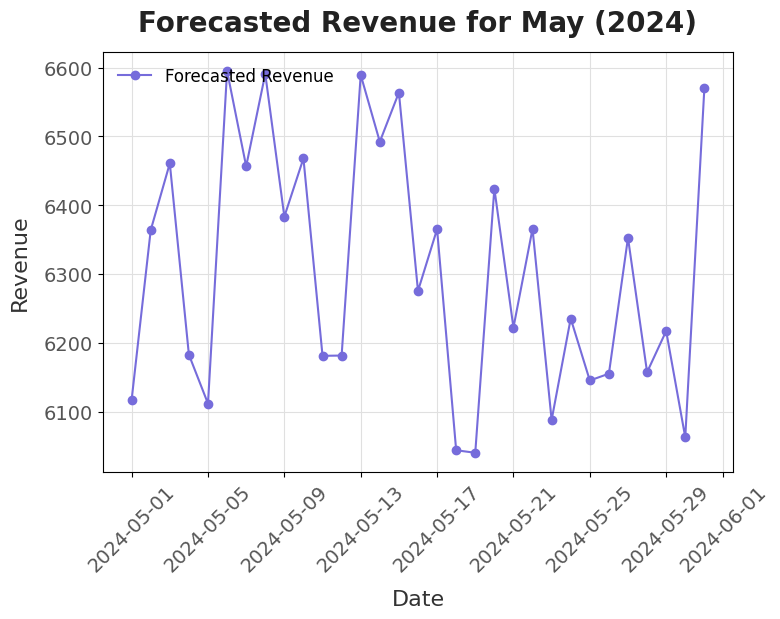

Forecasting completed for May 2024.


In [29]:
# Create a dataframe to hold predictions for the next 31 days
may = calendar[
    (calendar['Date'] >= '2024-05-01') & (calendar['Date'] <= '2024-05-31')
    ][['Date', 'Month', 'Day Type']].reset_index(drop=True)

# Add day number
may['Day'] = may['Date'].dt.day
may['Day of Week'] = may['Date'].dt.dayofweek

# Cyclical encoding
def encode_cyclical(df, col, max_val):
    df[col+'_sin'] = np.sin(2 * np.pi * df[col]/max_val)
    df[col+'_cos'] = np.cos(2 * np.pi * df[col]/max_val)
    return df

# Encode Day of Week column
may = encode_cyclical(may, 'Day of Week', 7)

# Binary flags
may['Is_Weekend'] = (may['Day Type'] == 'Weekend').astype(int)
may['Is_Holiday'] = (may['Day Type'] == 'Holiday').astype(int)

# Drop original temporal columns
may = may.drop(columns=['Day of Week', 'Day Type'])

# Display the new dataframe
# display(may)

# For forecasting, we assign median values for all features except those from the date
median_values = X.median()

# Build forecast dataframe with date features
forecast_df = may.copy()
# forecast_df = pd.DataFrame({'Date': forecast_dates})

# For remaining features, assign median values from training set
for col in ['Bookings', 'Journeys', 'First_Class']:
    forecast_df[col] = median_values[col]

# Arrange columns in the proper order
forecast_df = forecast_df[['Bookings', 'Journeys', 'First_Class', 'Is_Weekend', 'Is_Holiday', 'Day', 'Month', 'Day of Week_sin', 'Day of Week_cos']]

# Forecast computed revenue using the best model
forecast_df['Forecasted_Revenue'] = rf_model.predict(forecast_df[features])

# Display head of forecast dataframe
print('\nForecast Data Head:')
display(forecast_df)

# Plot the forecast
plt.figure(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.plot(may['Date'], forecast_df['Forecasted_Revenue'], color='#766CDB', marker='o', label='Forecasted Revenue')
plt.title('Forecasted Revenue for May (' + str(2024) + ')', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.xlabel('Date', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.ylabel('Revenue', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.xticks(rotation=45, fontsize=14, color='#555555')
plt.yticks(fontsize=14, color='#555555')
plt.grid(color='#E0E0E0')
plt.legend(fontsize=12, loc='upper left', frameon=False)
plt.gca().set_axisbelow(True)
plt.show()

print('Forecasting completed for May ' + str(2024) + '.')

In [30]:
print(f"\nPrediced Total Revenue for May 2024 = {forecast_df['Forecasted_Revenue'].sum().round(0).astype(int)} £")


Prediced Total Revenue for May 2024 = 195457 £


***